# Домашнее задание 2

В этом задании вам предстоит реализовать контрастивное обучние эмбеддера, посмотреть на его влияние на задаче классификации и отбора кандидатов.

Языковое моделирование рассматривать не будем в силу дороговизны подхода.

## Часть 1. Triplet loss на стероидах

Вам поставили задачу: на фиксированном множестве точек произвести классификацию, при этом множество таково, что качество на исходных данных неприемлемо. Что делать? Последуем совету из лекции и реализуем контрастивное обучение.

В этом и последующем задании вам предстоит реализовать дообучение некоторого простого эмбеддера на домен.

Эмбеддинги заморожены -- будем дообучать только полносвязную голову.

In [2]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from torch import nn
import logging
import torch.nn.functional as F

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s", force=True)
logger = logging.getLogger(__name__)

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = "cpu"
logger.info(f"Device: {DEVICE}")

2026-04-20 23:16:12,635 - __main__ - INFO - Device: cpu


In [3]:
SEED = 42


@dataclass
class DatasetConfig:
    n_samples: int = 5000
    n_features: int = 32
    n_classes: int = 8
    n_clusters_per_class: int = 2
    n_informative: int = 5
    random_state: int = SEED


@dataclass
class SplitConfig:
    random_state: int = SEED
    test_size: float = 0.25

In [4]:
X, y = make_classification(**DatasetConfig().__dict__)

X_train, X_test, y_train, y_test = train_test_split(X, y, **SplitConfig().__dict__)

X_train, y_train = (
    torch.from_numpy(X_train).float().to(DEVICE),
    torch.from_numpy(y_train).float().to(DEVICE),
)
X_test, y_test = (
    torch.from_numpy(X_test).float().to(DEVICE),
    torch.from_numpy(y_test).float().to(DEVICE),
)

## 1.Визуализация данных - 1 баллов

Напишите функцию `plot_tsne(data, labels, **kwargs)`, принимающую на вход матрицу эмбеддингов и метки классификации и строящую t-SNE-разложение на плоскости. Изобразите его, раскрасив классы по цветам. Зафиксируйте `random_state` при построении.

Цель задания: получить визуальное представление о природе распределения в данных. Для доменной адаптации визуализация - важный инструмент интерпретации результата.

In [5]:
import logging

import matplotlib.pyplot as plt
import seaborn as sns
from numpy.typing import ArrayLike, NDArray
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


# ---- Ваш код здесь ----

def type_cast(arg: ArrayLike) -> NDArray:
    if isinstance(arg, torch.Tensor):
        return arg.detach().cpu().numpy()

    if not isinstance(arg, np.ndarray):
        try:
            return np.asarray(arg)
        except Exception as e:
            logging.error("An error occured when type casting: %s", e)
            raise TypeError
    else:
        return arg


def plot_tsne(
    data: ArrayLike,
    labels: ArrayLike,
    plot_title: str,
    use_pca: bool,
    random_state: int,
    **tsne_kwargs,
):
    """
    Двумерная визуализация данных, для которых
    понижена размерность с помощью преобразование t-SNE.

    Parameters
    ----------
    data : ArrayLike
        Массив данных.
    labels : ArrayLike
        Массив меток (классов).
    plot_title : str
        Заколовок графика.
    """

    data = type_cast(data)
    labels = type_cast(labels)

    if use_pca:
        data = PCA(n_components=3, random_state=random_state).fit_transform(X=data)

    embedder = TSNE(**tsne_kwargs, random_state=random_state)
    data_tsne = embedder.fit_transform(X=data)

    sns.set_style("whitegrid")
    _ = sns.relplot(
        x=data_tsne[:, 0],
        y=data_tsne[:, 1],
        hue=labels.astype(np.int8),
        kind="scatter",
        palette="tab10" if len(np.unique(labels)) <= 10 else "tab20",
        alpha=0.5,
        height=7,
        size=10,
    )
    plt.suptitle(plot_title, y=1.05)
    plt.show()

# ---- Конец кода ----


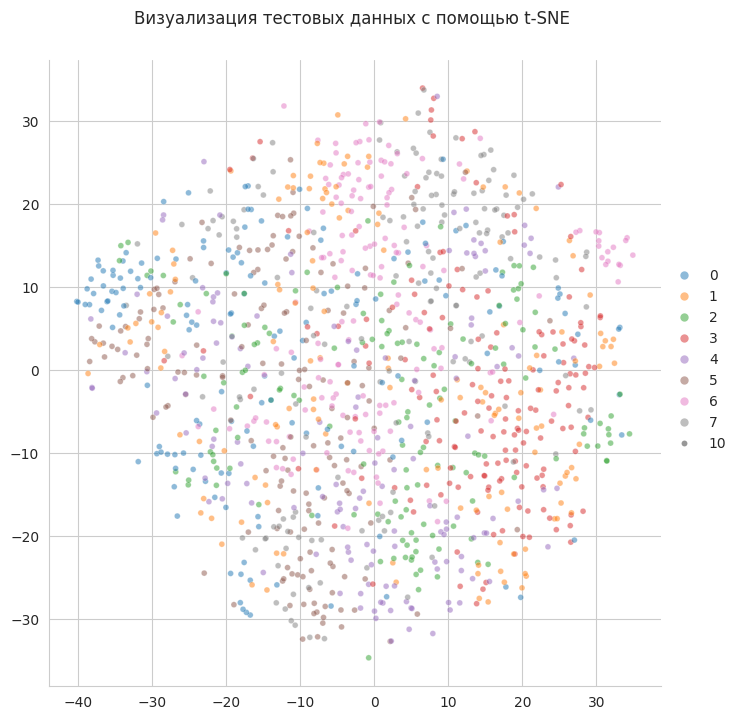

In [6]:
plot_tsne(X_test, y_test, plot_title="Визуализация тестовых данных с помощью t-SNE", use_pca=False, random_state=SEED)

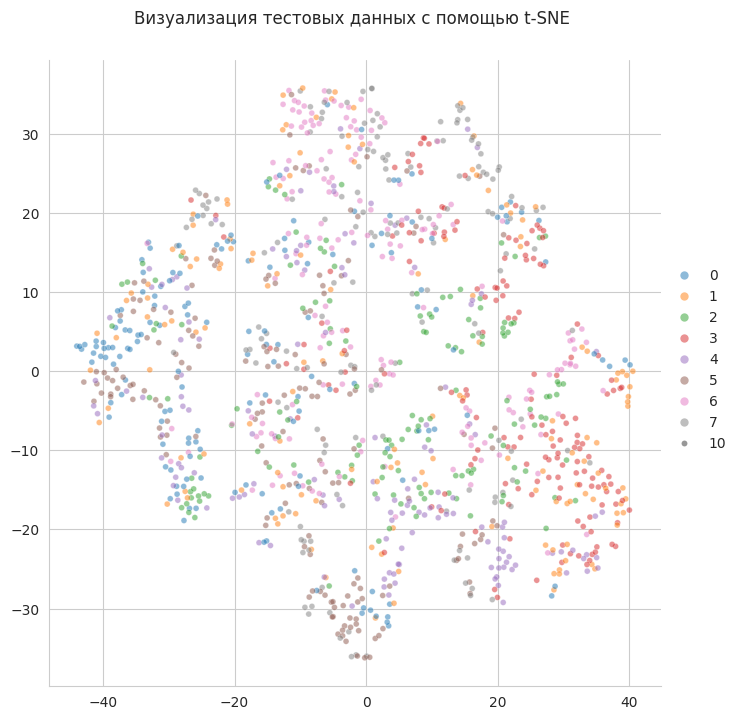

In [7]:
plot_tsne(X_test, y_test, plot_title="Визуализация тестовых данных с помощью t-SNE", use_pca=True, random_state=SEED)

## 2.Базовый классификатор

Выберем алгоритм классификации kNN и метрику качества Accuracy. Оценим базовое качество на тестовых данных.

In [8]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=10)
clf.fit(X_train.cpu().numpy(), y_train.cpu().numpy())

y_pred = clf.predict(X_test.cpu().numpy())
score = accuracy_score(y_test.cpu().numpy(), y_pred)

print(score)

0.5144


## 3.TripletLoss - 5 баллов

Давайте разберёмся, что такое Triplet Loss и как мы будем его использовать в несколько изменённом виде.

### Идея Triplet Loss

Цель обучения на Triplet Loss — научить модель отличать похожие объекты от непохожих. Для этого мы работаем с "триплетами" (тройками) векторов:

1.  **Якорь (`anchor`)**: Вектор нашего основного объекта $x$.
2.  **Позитив (`positive`)**: Вектор объекта $x^+$, который относится к тому же классу, что и якорь.
3.  **Негатив (`negative`)**: Вектор объекта $x^-$ из другого класса.

Цель — сделать так, чтобы в пространстве векторов "якорь" был ближе к "позитиву", чем к "негативу", причём с некоторым запасом (`margin`).

Функция ошибки Triplet Loss для одного триплета выглядит так:

$$\max\left(0,\|f(x)-f(x^+)\|^2_2-\|f(x)-f(x^-)\|^2_2+\varepsilon\right)$$

Заметим, что в случае L2-нормилизованных векторов:

$$\max\left(0,\|f(x)-f(x^+)\|^2_2-\|f(x)-f(x^-)\|^2_2+\varepsilon\right)=\max\left(0,f(x)f^T(x^-)-f(x)f^T(x^+)+\hat{\varepsilon}\right)$$

Пусть $D=\{x_i, y_i\}_i$ -- выборка классификации. Позитивные пары в $D$ формируются такими $(i,j)$, что $i \neq j$ и $y_i = y_j$, негативные - $i \neq j$ и $y_i \neq y_j$. Пусть $S=XX^T - \text{diag}(XX^T)$, где $\text{diag}(А)$ - преобразование квадратной матрицы $A$ к диагональной, в которой элементы на диагонали совпадают с диагональю $A$. То есть в $S$ диагональ занулена. По матрице $S$ можно сформировать два непересекающихся множества: позитивов $P$ и негативов $N$. Пусть $L$ -- минимальное количество элементов в каждом из двух множеств. Возьмем $\hat{P}=\{p_i\}_i$, $\hat{N}=\{n_i\}_i$ как сэмплы без возвращения размера $L$ из $P$ и $N$ соответственно. Тогда итоговая функция ошибки выглядит так:

$$\mathcal{L}=\frac{1}{L}\sum\limits_{i=1}^L\max\left(0, n_i-p_i+\hat{\varepsilon}\right)$$

В чем модификация? В том, что в паре позитивов и негативов не обязательно должен быть один и тот же якорный элемент. И это работает.

Реализуйте callable-класс `TripletLoss` по описанию.

Примечание: для прохождения тестов используйте сэмплирование через `np.random.default_rng(self.random_state).choice`.

In [9]:
# ---- Ваш код здесь ----

class TripletLoss(nn.Module):
    def __init__(self, margin: float, random_state: int):
        super().__init__()
        self.margin = margin
        self.random_state = random_state

    def forward(self, x: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        labels = labels.reshape(-1)
        x = F.normalize(x, p=2, dim=1)

        similarity_matrix = x @ x.T
        batch_size = x.size(0)

        labels_equal = labels[:, None] == labels[None, :]
        not_diagonal = ~torch.eye(
            batch_size,
            dtype=torch.bool,
            device=x.device,
        )

        positive_mask = labels_equal & not_diagonal
        negative_mask = ~labels_equal & not_diagonal

        positives = similarity_matrix[positive_mask]
        negatives = similarity_matrix[negative_mask]

        sample_size = min(positives.numel(), negatives.numel())
        if sample_size == 0:
            return x.sum() * 0.0

        positive_indices = np.random.default_rng(self.random_state).choice(
            positives.numel(), sample_size, replace=False
        )
        negative_indices = np.random.default_rng(self.random_state).choice(
            negatives.numel(), sample_size, replace=False
        )

        positive_samples = positives[positive_indices]
        negative_samples = negatives[negative_indices]

        losses = torch.relu(negative_samples - positive_samples + self.margin)
        return losses.mean()

# ---- Конец кода ----


In [10]:
criterion = TripletLoss(0.2, random_state=101)


objects = torch.tensor(
    [
        [
            -1.7651,
            -1.5979,
            0.1042,
            0.3825,
            -0.9419,
            -0.2580,
            -0.6087,
            -0.1711,
            1.3922,
            0.8548,
            -0.9251,
            0.6989,
            0.4238,
            -0.1330,
            0.2985,
        ],
        [
            1.6144,
            0.0627,
            0.3424,
            -0.8591,
            0.1869,
            -0.8598,
            -0.7200,
            0.9449,
            -0.1684,
            1.0282,
            -1.2377,
            -1.2640,
            0.7469,
            1.9605,
            -0.1214,
        ],
        [
            1.1143,
            -0.6948,
            0.3739,
            -1.1461,
            0.6456,
            -0.3360,
            -0.8111,
            -0.8861,
            0.7176,
            -0.6235,
            -0.9364,
            0.6174,
            2.7212,
            -2.0703,
            -2.2571,
        ],
        [
            0.7525,
            2.1028,
            2.7782,
            0.5040,
            -1.5791,
            1.5342,
            0.0816,
            0.3245,
            -0.0857,
            -0.5992,
            -1.4339,
            0.0897,
            -1.5096,
            0.1428,
            -0.1488,
        ],
        [
            -0.7518,
            0.2623,
            -0.4958,
            -1.6063,
            0.2537,
            -0.1137,
            0.3985,
            1.0155,
            0.1874,
            -0.4300,
            -1.2309,
            1.5760,
            -1.3176,
            1.5355,
            1.8471,
        ],
        [
            1.9290,
            -0.3236,
            0.4303,
            0.7111,
            1.4234,
            1.7901,
            0.2216,
            -1.5471,
            0.9389,
            -0.3012,
            -1.6487,
            1.5765,
            -1.1450,
            0.3260,
            0.4909,
        ],
        [
            0.7837,
            -0.8004,
            -0.0929,
            -1.2220,
            2.2333,
            0.3288,
            -0.5222,
            -0.7202,
            0.6147,
            1.8012,
            -0.2388,
            -0.2539,
            0.0191,
            -0.0104,
            0.5717,
        ],
        [
            -0.2709,
            -1.7985,
            -0.3959,
            -1.1190,
            0.8644,
            0.3008,
            -1.0336,
            -0.1251,
            -0.3357,
            0.7938,
            3.2090,
            -0.4332,
            -0.0496,
            -0.2672,
            0.9690,
        ],
        [
            -0.1109,
            0.4130,
            0.7406,
            -1.2446,
            -0.4252,
            2.5128,
            -0.2765,
            0.6845,
            1.1965,
            1.4173,
            -1.4604,
            0.2515,
            0.6387,
            -1.8519,
            1.1899,
        ],
        [
            -0.1781,
            -0.7473,
            -0.1015,
            0.2280,
            -1.5815,
            0.1535,
            -1.3912,
            -2.2026,
            1.0496,
            0.3547,
            0.8897,
            -0.6482,
            0.0133,
            1.0124,
            -0.4452,
        ],
    ]
)

labels = torch.LongTensor([1, 1, 2, 2, 3, 3, 4, 4, 5, 5])
assert abs(criterion(objects, labels).item() - 0.29527) < 1e-4

In [11]:
print(criterion(objects, labels).item())

0.295270711183548


## 4.Модель и функция обучения - 8 балла

Реализуйте функцию `domain_adaptation(X_train, y_train, hidden_dim, out_dim, margin, N_epoch, batches_per_epoch, batch_size) -> MLP`, базовый цикл batch-обучения линейной головы, полносвязной нейронной сети. Батч для обучения можно либо сэмплировать произвольно из всего обучающего множества через `random.choice`, либо заранее сделать случайную перестановку датасета, как итог пройти `batches_per_epoch` батчей из датасета за одну эпоху.

Используйте реализацию полносвязной нейронной сети через класс `MLP`.

Требуется выбить на тесте 0.60 точности.

Цель задания - закрепить использование `TripletLoss` на простых модельных данных.

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, out_dim, drop_prob=0.3):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.drop = nn.Dropout(drop_prob)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.drop(x)
        x = self.fc1(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        return x

In [13]:
# ---- Ваш код здесь ----

from typing import Optional
from torch.utils.data import DataLoader, TensorDataset


def sampling(
    X: torch.Tensor,
    y: torch.Tensor,
    random_state: int,
):
    """
    Сэмплирование данных для обучения модели.
    Перемешивает данные в случайном порядке,
    используя заданное значение random_state
    для воспроизводимости.
    """
    idxs = torch.randperm(
        X.size(0),
        generator=torch.Generator().manual_seed(random_state),
    )
    X = X[idxs]
    y = y[idxs]
    return X, y


def domain_adaptation(
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    hidden_dim: int,
    out_dim: int,
    drop_prob: float,
    lr: float,
    margin: float,
    N_epoch: int,
    random_state: int,
    batch_size: Optional[int] = None,
    batches_per_epoch: Optional[int] = None,
):
    """
    Обучение модели на тренировочных данных с помощью Triplet Loss.
    """
    torch.manual_seed(random_state)

    device = X_train.device
    logging.info("Using device: %s", device)

    dtype = X_train.dtype
    input_dim = X_train.size(1)
    y_train = y_train.reshape(-1).to(device=device)

    dataset = TensorDataset(X_train, y_train)
    generator = torch.Generator(device="cpu").manual_seed(random_state)

    if batches_per_epoch is not None:
        batch_size = len(X_train) // batches_per_epoch

    if batch_size is None and batches_per_epoch is None:
        batch_size = 8

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        generator=generator,
    )

    model = MLP(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        drop_prob=drop_prob,
    ).to(
        device=device,
        dtype=dtype,
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = TripletLoss(margin=margin, random_state=random_state)

    losses = []
    for epoch in range(N_epoch):
        model.train()
        epoch_loss = 0.0
        processed_batches = 0

        for batch_idx, (X_batch, y_batch) in enumerate(dataloader):
            X_batch = X_batch.to(device=device, dtype=dtype)
            y_batch = y_batch.to(device=device)

            embeddings = model(X_batch)
            loss = criterion(embeddings, y_batch)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            processed_batches += 1

        mean_epoch_loss = epoch_loss / max(processed_batches, 1)
        losses.append(mean_epoch_loss)

        if (epoch + 1) % 10 == 0:
            logging.info(
                "Epoch %d/%d, loss: %.6f",
                epoch + 1,
                N_epoch,
                mean_epoch_loss,
            )
        if device == "cuda":
            try:
                torch.cuda.empty_cache()
            except Exception as e:
                logging.warning("Failed to empty CUDA cache: %s", e)

    model.eval()
    return model, losses

# ---- Конец кода ----

In [14]:
model, losses = domain_adaptation(
    X_train,
    y_train,
    hidden_dim=64,
    out_dim=32,
    drop_prob=0.2,
    lr=1e-3,
    margin=0.1,
    N_epoch=100,
    batch_size=256,
    random_state=SEED,
)

2026-04-20 23:16:32,192 - root - INFO - Using device: cpu
2026-04-20 23:16:37,168 - root - INFO - Epoch 10/100, loss: 0.085476
2026-04-20 23:16:40,484 - root - INFO - Epoch 20/100, loss: 0.080711
2026-04-20 23:16:43,669 - root - INFO - Epoch 30/100, loss: 0.078640
2026-04-20 23:16:46,862 - root - INFO - Epoch 40/100, loss: 0.076377
2026-04-20 23:16:50,106 - root - INFO - Epoch 50/100, loss: 0.077145
2026-04-20 23:16:53,127 - root - INFO - Epoch 60/100, loss: 0.074780
2026-04-20 23:16:56,173 - root - INFO - Epoch 70/100, loss: 0.074157
2026-04-20 23:16:58,812 - root - INFO - Epoch 80/100, loss: 0.073495
2026-04-20 23:17:01,803 - root - INFO - Epoch 90/100, loss: 0.073364
2026-04-20 23:17:04,816 - root - INFO - Epoch 100/100, loss: 0.073240


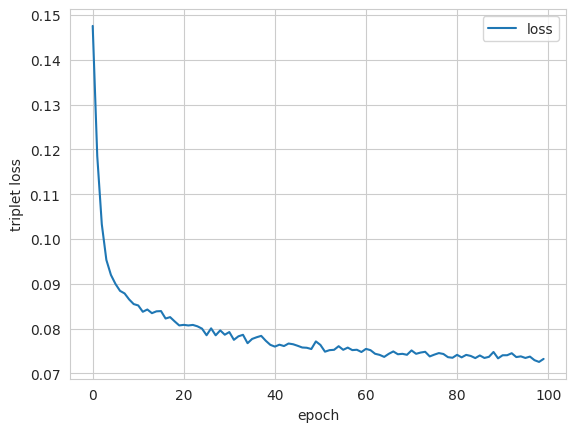

In [15]:
_ = pd.DataFrame(losses, columns=['loss']).plot(xlabel='epoch', ylabel='triplet loss')

In [16]:
model.eval()
with torch.no_grad():
    X_train_adapted = F.normalize(model(X_train), p=2, dim=1).cpu().numpy()
    X_test_adapted = F.normalize(model(X_test), p=2, dim=1).cpu().numpy()

In [17]:
clf = KNeighborsClassifier(n_neighbors=15)
clf.fit(X_train_adapted, y_train.cpu().numpy())

preds = clf.predict(X_test_adapted)
score_2 = accuracy_score(y_test.cpu().numpy(), preds)

print(score_2)

0.6448


## 5.Итоговое качество - 1 балл

Отобразите новое распределение t-SNE-координат и посчитайте тестовую метрику. Сделайте краткий вывод.

Что тут важно: перед тем, как применить kNN-классификатор, который несколько строчек кода назад был нашим baseline-решением, нужно применить над исходными данными преобразование обученной моделью представлений, фактически выходом функции `domain_adaptation`.

Цель задания: изучить, как поменялось распределение в данных после доменной адаптации.

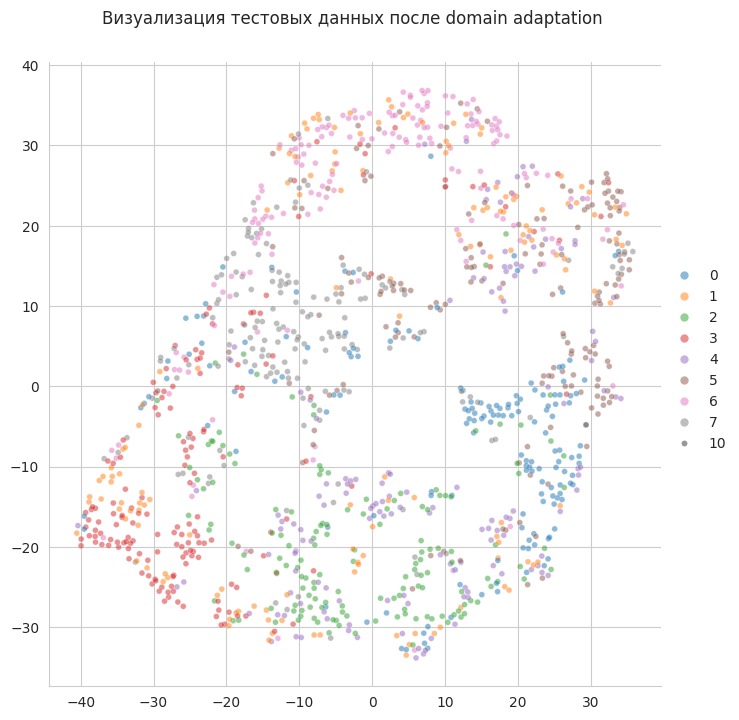

In [18]:
# ---- Ваш код здесь ----
plot_tsne(
    X_test_adapted,
    y_test,
    plot_title="Визуализация тестовых данных после domain adaptation",
    use_pca=True,
    random_state=SEED,
)
# ---- Конец кода ----


In [19]:
# ---- Ваш код здесь ----
print(f"Baseline accuracy: {score:.4f}")
print(f"Accuracy after domain adaptation: {score_2:.4f}")
# ---- Конец кода ----


Baseline accuracy: 0.5144
Accuracy after domain adaptation: 0.6448


## Часть 2. Triplet loss на чем-то посерьезнее

Рассмотрим теперь более живую задачу классификации. Будем работать с новостными группами.

Постановка та же, только возьмем теперь предобученный эмбеддер с HF. Эмбеддинги заморожены -- будем дообучать только полносвязную голову.

Поменяем так же алгоритм классификации с kNN на LogReg (по большей части для разнообразия).

In [20]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [21]:
categories = [
    "sci.space",
    "sci.med",
    "sci.electronics",
    "comp.os.ms-windows.misc",
    "comp.sys.ibm.pc.hardware",
    "comp.sys.mac.hardware",
]

newsgroups_train = fetch_20newsgroups(subset="train", categories=categories)
newsgroups_test = fetch_20newsgroups(subset="test", categories=categories)

X_train = newsgroups_train.data
X_test = newsgroups_test.data

y_train = newsgroups_train.target
y_test = newsgroups_test.target

In [22]:
def test_logreg(
    X_train_mapped,
    y_train,
    X_test_mapped,
    y_test,
    target_names=newsgroups_test.target_names,
):
    clf = LogisticRegression(max_iter=10000)
    clf.fit(X_train_mapped, y_train)

    y_pred = clf.predict(X_test_mapped)
    score = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names)

    print(f"Accuracy: {score:.3f}")
    print(f"Classification Report: {report}")

## 1.Выбираем англоязычный эмбеддер и формируем эмбеддинги - 1 балл

Выберите небольшой англоязычный sentence-трансформер, обученный на семантику, и прогоните через нее тексты обучения и тестирования.

Замерьте базовое качество классификатора на этих эмбеддингах.

Опционально: крайне рекомендую прогнать `plot_tsne` из прошлой части на тесте в тех же целях, что и в прошлых заданиях.

Цель задания: применить навыки выбора модели на основе описания ее области применения.

2026-04-20 23:17:18,001 - sentence_transformers.base.model - INFO - No device provided, using cuda:0


Определяем модель, получаем эмбеддинги, визуализируем тест через t-SNE


2026-04-20 23:17:18,782 - sentence_transformers.base.model - INFO - Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
2026-04-20 23:17:19,563 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/111 [00:00<?, ?it/s]

Batches:   0%|          | 0/74 [00:00<?, ?it/s]

Accuracy: 0.827
Classification Report:                           precision    recall  f1-score   support

 comp.os.ms-windows.misc       0.82      0.84      0.83       394
comp.sys.ibm.pc.hardware       0.74      0.69      0.72       392
   comp.sys.mac.hardware       0.78      0.78      0.78       385
         sci.electronics       0.76      0.76      0.76       393
                 sci.med       0.94      0.95      0.94       396
               sci.space       0.92      0.93      0.93       394

                accuracy                           0.83      2354
               macro avg       0.83      0.83      0.83      2354
            weighted avg       0.83      0.83      0.83      2354



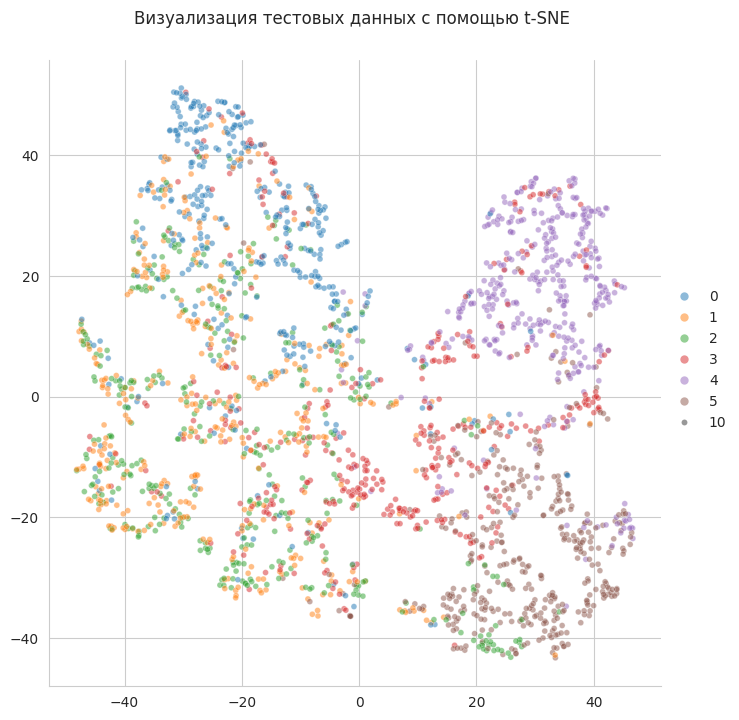

In [23]:
import torch
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

# ---- Ваш код здесь ----
print("Определяем модель, получаем эмбеддинги, визуализируем тест через t-SNE")

logging.getLogger("httpx").setLevel(logging.WARNING)


# model = SentenceTransformer("yodayo-ai/jina-embeddings-v2-small-en-st", device="cpu")
# model = SentenceTransformer("BAAI/bge-small-en-v1.5", device="cpu")
# model = SentenceTransformer("opensearch-project/opensearch-neural-sparse-encoding-doc-v2-mini", device="cpu")

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

torch.cuda.empty_cache()
X_train_mapped = model.encode(X_train, show_progress_bar=True, chunk_size=16)
X_train_mapped = F.normalize(torch.from_numpy(X_train_mapped), p=2, dim=1).cpu().numpy()

X_test_mapped = model.encode(X_test, show_progress_bar=True, chunk_size=16)
X_test_mapped = F.normalize(torch.from_numpy(X_test_mapped), p=2, dim=1).cpu().numpy()

test_logreg(X_train_mapped, y_train, X_test_mapped, y_test)

plot_tsne(
    X_test_mapped,
    y_test,
    plot_title="Визуализация тестовых данных с помощью t-SNE",
    use_pca=True,
    random_state=SEED,
)
# ---- Конец кода ----


## 2.Обучаем эмбеддинги под задачу - 1 балл

Теперь точно придется обратиться к Части 1. Необходимо взять `domain adaptation` и обучить эмбеддиги на домен. Выходом будет линейная голова, как и в прошлой части, которую мы применим как преобразование исходных данных для улучшения представления и более качественного решения конечной задачи, в данном случае классификации.

2026-04-20 23:18:46,476 - root - INFO - Using device: cpu


Доменно адаптируемся


2026-04-20 23:18:55,380 - root - INFO - Epoch 10/30, loss: 0.114830
2026-04-20 23:19:04,136 - root - INFO - Epoch 20/30, loss: 0.043061
2026-04-20 23:19:13,156 - root - INFO - Epoch 30/30, loss: 0.021739


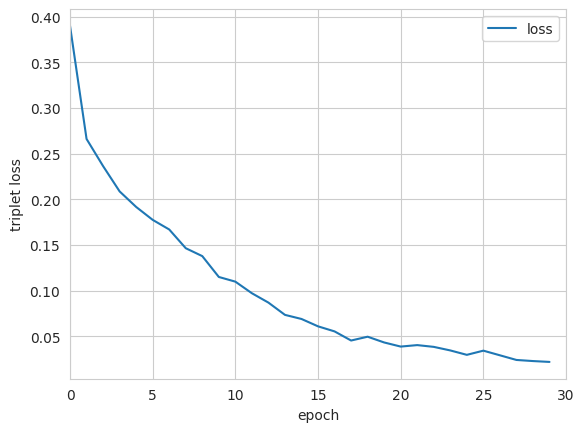

In [24]:
# ---- Ваш код здесь ----
print("Доменно адаптируемся")

model, losses = domain_adaptation(
    torch.tensor(X_train_mapped, dtype=torch.float32, device=DEVICE),
    torch.tensor(y_train, device=DEVICE),
    hidden_dim=1024,
    out_dim=X_train_mapped.shape[1],
    drop_prob=0.3,
    lr=1e-2,
    margin=1,
    N_epoch=30,
    random_state=SEED,
    batch_size=128,
)

_ = pd.DataFrame(losses, columns=['loss']).plot(xlabel='epoch', ylabel='triplet loss', use_index=True, xlim=(0,30))

# ---- Конец кода ----


## 3.Замеряем качество - 1 балл

Обучитите базовый классификатор на новом пространстве эмбеддингов, сравните результаты с baseline-решением, полученным через функцию `test_logreg` выше, обязательно сделайте вывод.

На всякий случай, в этом задании вам тоже нужно вызвать `test_logreg`, только с другими аргументами (новым преобразованием данных).

Опционально: вновь крайне рекомендую прогнать `plot_tsne` из прошлой части на тесте, только уже в новом пространстве.

Примечание: в референсном решении качество растет с $0.821$ до $0.879$.

Радуемся росту качества


Accuracy: 0.874
Classification Report:                           precision    recall  f1-score   support

 comp.os.ms-windows.misc       0.87      0.85      0.86       394
comp.sys.ibm.pc.hardware       0.79      0.78      0.78       392
   comp.sys.mac.hardware       0.81      0.85      0.83       385
         sci.electronics       0.86      0.86      0.86       393
                 sci.med       0.97      0.96      0.96       396
               sci.space       0.94      0.95      0.95       394

                accuracy                           0.87      2354
               macro avg       0.87      0.87      0.87      2354
            weighted avg       0.87      0.87      0.87      2354



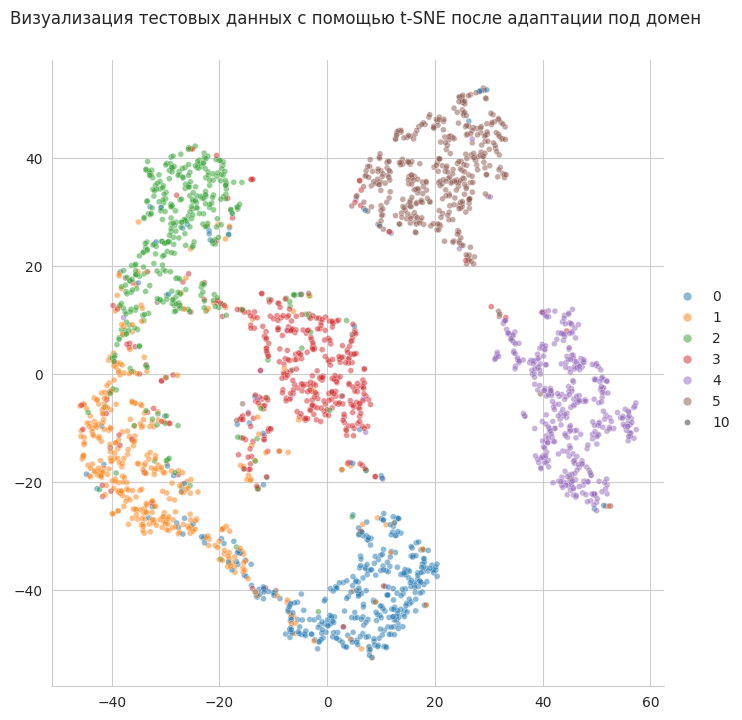

In [25]:
# ---- Ваш код здесь ----

print("Радуемся росту качества")

model.eval()
with torch.no_grad():
    X_train_adapted = (
        F.normalize(
            model(torch.tensor(X_train_mapped, dtype=torch.float32, device=DEVICE)),
            p=2,
            dim=1,
        )
        .cpu()
        .numpy()
    )
    X_test_adapted = (
        F.normalize(
            model(torch.tensor(X_test_mapped, dtype=torch.float32, device=DEVICE)),
            p=2,
            dim=1,
        )
        .cpu()
        .numpy()
    )

test_logreg(X_train_adapted, y_train, X_test_adapted, y_test)

plot_tsne(
    X_test_adapted,
    y_test,
    plot_title="Визуализация тестовых данных с помощью t-SNE после адаптации под домен",
    use_pca=True,
    random_state=SEED,
)

# ---- Конец кода ----


# Часть 3. Контрастивное обучение для поискового отбора кандидатов.

Эта часть будет более кейс-ориентированной, мы разберем сценарий, в котором контрастивное обучение является стандартной практикой улучшения качества модели на конечной задаче.

Бизнес-кейс:
> Требуется улучшить этап отбора кандидатов в поисковой веб-системе. На текущий момент в качестве кандгена (кандидатогенерации) используется BM25 и обратный индекс. BM25 уже тюнили, дальше качество нарастить не выходит. В качестве бизнес-метрики можем взять производные поведенческого отклика, например, CTR@K или timespent на выдаче и документах.

Очевидным направлением развития является построение нейросетевого кандгена. Обычно в описанных случаях действуют следующим образом:

0. Выбирают ML-метрику, которую хотелось бы оптимизировать. Для кандгена катастрофически важно выдать как можно больше релеватных документов в пределах фиксированной длины выдачи, поэтому подходящая метрика -- Recall@K. Мы будем использовать ее модификацию, но об этом позже.
1. Сэмплируют запросы из потока / формируют специфичные корзины запросов в зависимости от дополнительных бизнес-требований. Давайте считать, что они отсутствуют. Тут обязателен контроль их качества, можно исходить из символьных эвристик или применять LLM для классификации, как вы это делали в предыдущей домашке.
2. Обкачивают поисковый движок, формируя глубокие выдачи. Эпитет "глубокие" относится к глубине погружения пользователя в выдачу, то есть предельные позиции взаимодействия с документами. Так вот для обучения требуется брать документов в избытке, в том числе те, с которыми пользователь никогда бы не повзаимодействовал. В целом, длина выдачи 1000 -- отличный выбор. В качестве ремарки, обычно в данном случае прибегают к выкручиванию параметров отбора по BM25 для гарантированно длинной выдачи.
3. Разметка пар запрос-документ на задачу релевантности. LLM -- вновь отличный выбор. Разметка порядковая, но может быть как бинарной, так и n-арной. Релевантность - относительное понятие, отсюда следует, что множество возможных значений релевантности является упорядоченным. Важно сформировать определение "релевантного" документа, то есть определить порог, по которому мы будем считать документ подходящим под запрос. Порогом в данном случае является некоторое значение из множества всевозможных значений релевантности, которое является минимальным для определения позитивности пары запрос-документ.
4. Релевантные пары запрос-документ берем в качестве позитивов, выбираем базовый эмбеддер и учим его контрастивно как bi-энкодер на эту выборку, негативы можем формировать в режиме in-batch.
5. Если все сделано верно (данных достаточно, гиперпараметры подобраны, код не багованный), естественным следствием будет рост качества, поздравляю.

Датасет, на котором мы будем строить кандген -- MS Marco Dev. В качестве эмбеддера вы вольны использовать любые модели, которые не учились на MS Marco, например, `"microsoft/deberta-v3-small"`.

Мы привыкли в основном, что датасеты собраны на HF, но в этот раз рассмотрим другую библиотеку для работы с датасетами, `ir_datasets` ([API](https://ir-datasets.com/python.html)). "IR" от Information Retrieval - библиотека содержит инструменты работы с датасетами поиска. Также в коде будет использоваться `polars` ([API](https://docs.pola.rs/api/python/stable/reference/index.html)), аналог всеми известной `pandas`, только на порядки быстрее.

Описание датасета читайте [тут](https://ir-datasets.com/msmarco-passage.html#msmarco-passage/dev/judged).

In [26]:
try:
    import faiss
except ImportError:
    !pip install -q faiss-gpu

try:
    import ir_datasets
except ImportError:
    !pip install -q ir_datasets

2026-04-20 23:19:29,493 - faiss._loader - INFO - Loading faiss with AVX512 support.
2026-04-20 23:19:29,494 - faiss._loader - INFO - Could not load library with AVX512 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx512'")
2026-04-20 23:19:29,495 - faiss._loader - INFO - Loading faiss with AVX2 support.
2026-04-20 23:19:29,496 - faiss._loader - INFO - Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
2026-04-20 23:19:29,497 - faiss._loader - INFO - Loading faiss.
2026-04-20 23:19:29,598 - faiss._loader - INFO - Successfully loaded faiss.


In [27]:
import re
import logging
from collections import defaultdict
from dataclasses import dataclass
from functools import partial

import faiss
import ir_datasets
import numpy as np
import polars as pl
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer

In [28]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [29]:
@dataclass
class Columns:
    query_id: str = "query_id"
    doc_id: str = "doc_id"
    index_id: str = "index_id"
    text: str = "text"
    qrels_relevance: str = "relevance"


@dataclass
class DatasetConfig:
    sampled_index_size: int = 150_000
    relevance_threshold: int = 1
    test_size: float = 0.2

In [30]:
dataset = ir_datasets.load("msmarco-passage/dev/judged")

columns = Columns()
dataset_config = DatasetConfig()

In [31]:
# queries = pl.DataFrame(dataset.queries_iter()).select(
#     pl.col(columns.query_id).cast(pl.Int32), pl.col(columns.text)
# )

# qrels = (
#     pl.DataFrame(dataset.qrels_iter())
#     .drop("iteration")
#     .select(
#         pl.col(columns.query_id).cast(pl.Int32),
#         pl.col(columns.doc_id).cast(pl.Int32),
#         pl.col(columns.qrels_relevance).cast(pl.Int32),
#     )
# )

# documents = pl.DataFrame(dataset.docs_iter()).select(
#     pl.col(columns.doc_id).cast(pl.Int32), pl.col(columns.text)
# )

In [32]:
# queries.write_parquet("/content/drive/MyDrive/queries.parquet")
# qrels.write_parquet("/content/drive/MyDrive/qrels.parquet")
# documents.write_parquet("/content/drive/MyDrive/documents.parquet")

In [33]:
# queries = pl.read_parquet("/content/drive/MyDrive/queries.parquet")
# qrels = pl.read_parquet("/content/drive/MyDrive/qrels.parquet")
# documents = pl.read_parquet("/content/drive/MyDrive/documents.parquet")

In [34]:
queries = pl.read_parquet("./data/queries.parquet")
documents = pl.read_parquet("./data/documents.parquet")


In [35]:
qrels = pl.read_parquet("./data/qrels.parquet")

# DEBUG
# qrels = qrels.limit(10_000)

In [36]:
target_document_ids = qrels[columns.doc_id].unique().to_list()
sampled_document_ids = (
    np.random.default_rng()
    .integers(dataset.docs_count(), size=dataset_config.sampled_index_size)
    .tolist()
)

sampled_documents = documents.filter(
    pl.col(columns.doc_id).is_in(sampled_document_ids + target_document_ids)
).with_row_index(columns.index_id)
len(target_document_ids), len(sampled_document_ids)

(59096, 150000)

In [37]:
train_qrels, test_qrels = train_test_split(
    qrels,
    test_size=dataset_config.test_size,
    random_state=seed,
    shuffle=True,
)

train_queries = queries.filter(
    pl.col(columns.query_id).is_in(train_qrels[columns.query_id].implode())
)
test_queries = queries.filter(
    pl.col(columns.query_id).is_in(test_qrels[columns.query_id].implode())
)

train_documents = sampled_documents.filter(
    pl.col(columns.doc_id).is_in(train_qrels[columns.doc_id].implode())
)
test_documents = sampled_documents.filter(
    pl.col(columns.doc_id).is_in(test_qrels[columns.doc_id].implode())
)


In [38]:
# Познакомимся с даннымим

pl.Config.set_fmt_str_lengths(150)

display(
    train_qrels.join(
        train_documents,
        left_on=columns.doc_id,
        right_on=columns.doc_id,
        how="inner",
        suffix="_documents",
    ).join(
        train_queries,
        left_on=columns.query_id,
        right_on=columns.query_id,
        how="inner",
        suffix="_queries",
    ),
    train_qrels.select(pl.col("relevance").value_counts()).unnest("relevance"),
    test_qrels.select(pl.col("relevance").value_counts()).unnest("relevance"),
)

query_id,doc_id,relevance,index_id,text,text_queries
i32,i32,i32,u32,str,str
80758,6913169,1,124305,"""A handful of plants will provide you with enough oregano to use fresh in season and to dry for use throughout the winter. There are many varieties, bu…","""can you use oregano flowers"""
610919,6125330,1,110314,"""Sponsored Topics. Oxford is a town in Chenango County, New York, United States. The town contains a village named Oxford. Oxford is an interior town i…","""what county is oxford ny in?"""
1100271,6716665,1,120779,"""Giardiasis is a diarrheal disease caused by the microscopic parasite Giardia. A parasite is an organism that feeds off of another to survive. Once a p…","""giardiasis definition"""
1090648,7980184,1,191012,"""Silverpoint definition, a technique of drawing with a silver stylus on specially prepared paper. See more.""","""silverpoint definition"""
1059370,7169778,1,135364,"""Contact the Commission. Virginia Workers' Compensation Commission, 1000 DMV Drive, Richmond, VA 23220. For general questions, please contact the Custo…","""compensation commissioner telephone number"""
…,…,…,…,…,…
937662,7925649,1,187422,"""Can You Stand the Rain. Single by New Edition. Can You Stand the Rain is a ballad by R&B/pop group New Edition. Released in 1988, it is the third sing…","""when did can you stand the rain come out"""
602990,7665378,1,169878,"""Belfry Kentucky DDL & MVL Nearby Offices. 1 Circuit Court Clerk's Office 175 Main Street. 2 Driver License Branch Highway 194. 3 County Clerk's Off…","""what county is belfry wv located?"""
1089779,7081462,1,127969,"""List of polyglots. A polyglot is a person with a command of many languages. A polyglot may also be called a multilingual person; the label multilingua…","""the meaning of polyglot"""


relevance,count
i32,u32
1,47418


relevance,count
i32,u32
1,11855


## 0.Дополните параметры конфигов в зависимости от вашей реализации модели и обучения

Задайте параметры токенизации, обучения, значения параметров функции ошибки и дополнительные параметры модели.
Что стоит добавить в конфиг модели:
- возможность заморозить хвост и дообучать только голову (делается через регулярки и `model.named_parameters()`)
- снижение размерности за счет дополнительной полносвязной сети
- параметры для этой дополнительной сети

Описание полей конфига функции ошибки читай ниже.

In [39]:
@dataclass
class TrainTestConfig:
    device: torch.device = torch.device(["cpu", "cuda"][torch.cuda.is_available()])
    batch_size: int = 16
    inference_batch_size: int = 16
    num_epochs: int = 1
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    gradient_accumulation_steps: int = 2
    max_grad_norm: float = 1.0
    max_query_length: int = 100
    max_doc_length: int = 300
    recall_at: tuple[int, ...] = (10, 50, 100)
    relevance_threshold: int = 1
    eval_every_n_epochs: int = 1
    num_workers: int = 0
# ---- Конец кода ----


@dataclass
class ModelConfig:
    model_name: str
    freeze_backbone: bool = True
    projection_dim: int | None = None
# ---- Конец кода ----


@dataclass
class LossConfig:
    thrsh: float = 0.1
    
    temperature: float = 0.1
    reverse_loss_weight: float = 0.2


# ---- Конец кода ----


In [40]:
columns = Columns()
dataset_config = DatasetConfig()
train_test_config = TrainTestConfig()

# ---- Ваш код здесь ----
model_config = ModelConfig("microsoft/deberta-v3-small", projection_dim=128)
loss_config = LossConfig()
# ---- Конец кода ----


## 1.Датасет - 4 баллов

Напишите класс `DenseRetrievalDataset`, наследованный от `Dataset`, который внутри формирует множество релевантных пар и выдает на каждый индекс произвольную пару оттуда вместе с `query_id` и `doc_id`. Эта функциональность должна быть инкапсулирована в методе `_build_positive_pairs`. Обратите внимание на `relevance_threshold` из конфига датасета, используйте ее для формирования позитивных пар.

Напишите также функцию `train_collate_fn` для DataLoader'а, которая внутри токенизирует батчем текст запроса и документа и отдает кортеж из тензоров, в которые включаются id запросов и документов, токены запросов и документов.

In [41]:
from typing import Any


class DenseRetrievalDataset(Dataset):
    def __init__(
        self,
        queries: pl.DataFrame,  # ['query_id', 'text']
        documents: pl.DataFrame,  # ['index_id', 'doc_id', 'text']
        qrels: pl.DataFrame,  # ['query_id', 'doc_id', 'relevance']
        columns: Columns,
        config: DatasetConfig,
    ):
        self.columns = columns
        self.config = config

        self.queries = queries
        self.documents = documents
        self.qrels = self._build_positive_pairs(qrels).with_row_index("index")

    def _build_positive_pairs(self, qrels) -> pl.DataFrame:
        return (
            qrels.join(
                self.documents.with_columns(pl.col("text").alias("doc")),
                left_on=self.columns.doc_id,
                right_on=self.columns.doc_id,
                how="inner",
            )
            .join(
                self.queries.with_columns(pl.col("text").alias("query")),
                left_on=self.columns.query_id,
                right_on=self.columns.query_id,
                how="inner",
            )
            .select(
                self.columns.index_id,
                self.columns.query_id,
                self.columns.doc_id,
                "query",
                "doc",
                self.columns.qrels_relevance,
            )
            .filter(
                pl.col(self.columns.qrels_relevance) >= self.config.relevance_threshold
            )
        )

    def __getitem__(self, index) -> dict[str, Any]:
        return (
            self.qrels
            .select(
                "index",
                pl.col(self.columns.query_id),
                pl.col(self.columns.doc_id),
                pl.col("query"),
                pl.col("doc"),
            )
            .row(index, named=True)
        )

    def __len__(self) -> int:
        return self.qrels.height


# ---- Конец кода ----


In [42]:
# Test dataset

d = DenseRetrievalDataset(
    train_queries,
    train_documents,
    train_qrels,
    columns,
    dataset_config,
)

d[17]

{'index': 17,
 'query_id': 805900,
 'doc_id': 7858013,
 'query': 'what is the average cost of a home in santa rosa california',
 'doc': 'The cost of living in Santa Rosa is 40% higher than the national average. The cost of housing in Santa Rosa is 89% higher than the national average. California general sales tax is 47% higher than the national average. California state income tax is 55% lower than the national average.'}

In [43]:
def train_collate_fn(data, tokenizer, config) -> tuple[torch.Tensor, ...]:
    # ---- Ваш код здесь ----
    query_ids = torch.tensor([item["query_id"] for item in data], dtype=torch.long)
    doc_ids = torch.tensor([item["doc_id"] for item in data], dtype=torch.long)
    queries = [item["query"] for item in data]
    docs = [item["doc"] for item in data]

    query_tokens = tokenizer(
        queries,
        padding=True,
        truncation=True,
        max_length=config.max_query_length,
        return_tensors="pt",
    )
    doc_tokens = tokenizer(
        docs,
        padding=True,
        truncation=True,
        max_length=config.max_doc_length,
        return_tensors="pt",
    )

    return (
        query_ids,
        doc_ids,
        query_tokens,
        doc_tokens,
    )
    # ---- Конец кода ----

## 2.Функция ошибки - 5 баллов

Реализуйте класс `ContrastiveLoss`, который реализует расчет следующей функции ошибки:
$$\mathcal{L}=\mathbb{E}_C\text{CrossEntropy}\left(\frac{q_iD^T}{\tau}-B_i, M_i\right)$$
$$C=\{Q, D\},\quad Q=\{q_i\big|q_i\in\mathbb{R}^n,\|q_i\|_2=1\}_{i=1}^N,\quad D=\{d_i\big|d_i\in\mathbb{R}^n,\|d_i\|_2=1\}_{i=1}^N$$
$$(q_i, d_i) \,-\,\text{позитивная пара}$$

Здесь $C$ - батч запросов-документов, где на соответствующих индексах $i$ стоят заведомо позитивные пары, $\tau$ - температура, регулирующая "агрессивность" сближения позитивных пар.

В качестве таргетов в кросс-энтропии используются $M_i$. Перед тем, как выписать его формулу, введем обозначение $\text{QID}_i$ как id запроса, эмбеддинг которого - $q_i$, в коде это `query_id` в датасете запросов. $M_i$ вычисляется следующим образом:

$$M_i\in[0,1]^N,\quad \forall{j}\in\overline{1,N}:\;M[j]=\frac{[\text{QID}_i = \text{QID}_j]}{\sum\limits_k{[\text{QID}_i = \text{QID}_k]}}$$

Фактически это вероятностный вектор, где ненулевые элементы соответствуют позитивным парам. Для того, чтобы избежать необходимости дедублицировать батч по запросам (по $\text{QID}$), формула подразумевает равномерное "размазывание" вероятности по одинаковым запросам из батча.

Внутри формулы добавлен параметр $B_i$, который формулируется следующим образом:
$$B_i\in[0,1]^N,\quad \forall{j}\in\overline{1,N}:\;M[j]=b*[q_i = q_j]$$
$$b\,-\,\text{вещественный гиперпараметр}$$

Смысл $b$ смотрите в [статье LaBSE](https://arxiv.org/pdf/2007.01852), _Additive Margin Softmax_. Если нет времени разбираться, задайте $b$ равным $0$.

Фактически вы напишите `InfoNCE` с in-batch-негативами.

Подсказка: не упаковывайте расчет $M_i$ внутрь функции ошибки, сделайте ее внешней. Она вам пригодится в функции обучения.

In [44]:
# ---- Ваш код здесь ----
class ContrastiveLoss(nn.Module):
    def __init__(self, thrsh, temperature):
        super().__init__()
        self.thrsh = thrsh
        self.temperature = temperature

    def forward(self, queries, documents, labels):
        queries = F.normalize(queries, p=2, dim=-1, eps=1e-8)
        documents = F.normalize(documents, p=2, dim=-1, eps=1e-8)
        labels = labels.to(device=queries.device, dtype=queries.dtype)

        logits = queries @ documents.T / self.temperature
        positive_margin = (labels > 0).to(dtype=queries.dtype) * self.thrsh
        logits = logits - positive_margin

        log_probs = F.log_softmax(logits, dim=-1)
        return -(labels * log_probs).sum(dim=-1).mean()


# ---- Конец кода ----


def build_label_mask(entity_ids):
    mask = (entity_ids.view(-1, 1) == entity_ids.view(1, -1)).float()
    mask = mask / mask.sum(dim=-1, keepdim=True).clamp_min(1.0)
    return mask

In [45]:
criterion = ContrastiveLoss(0.1, 0.05)


queries = torch.tensor(
    [
        [
            0.5803,
            0.9579,
            -1.7393,
            0.8502,
            1.0579,
            1.1222,
            -1.3303,
            2.1554,
            -0.2404,
            1.7580,
            0.1433,
            0.6232,
            -0.9371,
            0.7069,
            0.9060,
        ],
        [
            1.4968,
            -0.4212,
            -0.3566,
            -0.1982,
            0.3722,
            0.4442,
            1.0164,
            0.8380,
            -0.5248,
            -1.1686,
            1.3973,
            -0.6910,
            -0.5832,
            -0.2636,
            -1.0497,
        ],
        [
            0.1836,
            -1.2159,
            -0.5191,
            -1.5825,
            0.4003,
            -0.6419,
            -1.1341,
            0.2970,
            -1.1792,
            2.1851,
            2.3077,
            0.3735,
            1.4981,
            0.6243,
            1.2269,
        ],
        [
            -2.7559,
            -0.2543,
            0.6742,
            -0.0188,
            -0.3204,
            0.2138,
            0.2517,
            -2.2059,
            -1.3797,
            -1.5980,
            -1.3527,
            1.5497,
            -0.7449,
            0.6207,
            -1.8088,
        ],
        [
            0.7241,
            1.2993,
            0.8433,
            0.1442,
            -1.0798,
            1.7103,
            0.0768,
            -1.0067,
            -0.4282,
            0.7578,
            -0.0629,
            -0.4202,
            0.8126,
            -0.1174,
            0.8947,
        ],
        [
            1.7049,
            -0.6559,
            0.4521,
            -0.4866,
            0.2823,
            -0.0065,
            -0.6142,
            0.9237,
            -0.6907,
            0.6034,
            0.2700,
            1.0026,
            0.9323,
            1.3452,
            -1.1236,
        ],
    ]
)

documents = torch.tensor(
    [
        [
            0.8498,
            1.4255,
            -1.3913,
            -0.0906,
            2.6704,
            -1.5063,
            -1.5604,
            -0.4563,
            0.4762,
            0.7897,
            -0.1102,
            0.1176,
            0.3902,
            1.5095,
            -0.3534,
        ],
        [
            -0.9154,
            -0.1968,
            0.5091,
            0.0156,
            -1.6841,
            -1.1580,
            1.2767,
            2.6576,
            -0.3602,
            0.4782,
            0.7819,
            0.7402,
            -0.8883,
            -0.1158,
            1.0545,
        ],
        [
            -0.8661,
            0.3513,
            -1.8400,
            -3.5891,
            -1.3286,
            -0.1409,
            -1.3466,
            1.1086,
            0.4160,
            2.5859,
            0.0813,
            -0.5245,
            0.1244,
            0.3139,
            1.2755,
        ],
        [
            0.1836,
            -1.2159,
            -0.5191,
            -1.5825,
            0.4003,
            -0.6419,
            -1.1341,
            0.2970,
            -1.1792,
            2.1851,
            2.3077,
            0.3735,
            1.4981,
            0.6243,
            1.2269,
        ],
        [
            -1.2163,
            0.2481,
            -1.9740,
            0.2509,
            1.0521,
            0.5903,
            -0.6070,
            -0.6650,
            -0.1618,
            0.5526,
            0.6654,
            0.9530,
            -0.5084,
            1.8372,
            -0.2625,
        ],
        [
            1.4968,
            -0.4212,
            -0.3566,
            -0.1982,
            0.3722,
            0.4442,
            1.0164,
            0.8380,
            -0.5248,
            -1.1686,
            1.3973,
            -0.6910,
            -0.5832,
            -0.2636,
            -1.0497,
        ],
    ]
)

labels = torch.eye(queries.size(0))
assert abs(criterion(queries, documents, labels).item() - 8.74177) < 1e-3

labels = torch.tensor(
    [
        [0.5000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000],
        [0.0000, 0.3333, 0.0000, 0.3333, 0.0000, 0.3333],
        [0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3333, 0.0000, 0.3333, 0.0000, 0.3333],
        [0.5000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000],
        [0.0000, 0.3333, 0.0000, 0.3333, 0.0000, 0.3333],
    ]
)
assert abs(criterion(queries, documents, labels).item() - 7.47976) < 1e-3

In [46]:
print(criterion(queries, documents, labels).item())

7.47975492477417


## 3.Модель - 4 баллов

Реализуйте класс `Embedder`, который возвращает матрицу эмбеддингов по выходу токенизатора. Вы вольны выбирать архитектуру, но суть работы модели должна сохраняться.

In [47]:
class Embedder(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()
        # ---- Ваш код здесь ----
        self.config = config
        self.model = AutoModel.from_pretrained(config.model_name).float()
        self.tokenizer = AutoTokenizer.from_pretrained(config.model_name)
        self.freeze_backbone = config.freeze_backbone

        hidden_size = self.model.config.hidden_size
        projection_dim = config.projection_dim or hidden_size
        self.projection = nn.Linear(hidden_size, projection_dim, bias=False)
        if projection_dim == hidden_size:
            nn.init.eye_(self.projection.weight)

        if self.freeze_backbone:
            self.model.eval()
            for parameter in self.model.parameters():
                parameter.requires_grad = False

    def forward(self, tokens):
        if self.freeze_backbone:
            self.model.eval()
            with torch.no_grad():
                outputs = self.model(**tokens)
        else:
            outputs = self.model(**tokens)

        hidden_states = outputs.last_hidden_state.float()
        attention_mask = tokens["attention_mask"].unsqueeze(-1).type_as(hidden_states)
        pooled = (hidden_states * attention_mask).sum(dim=1)
        pooled = pooled / attention_mask.sum(dim=1).clamp(min=1e-9)
        projected = self.projection(pooled)
        return F.normalize(projected, p=2, dim=-1, eps=1e-8)


# ---- Конец кода ----


In [48]:
# Test embedder

embedder = Embedder(model_config)

print(embedder.tokenizer(d[17]["query"]))
print(embedder.tokenizer(d[17]["doc"]))

embedder.eval()
with torch.no_grad():
    tokens = embedder.tokenizer(
        [d[17]["query"],d[17]["doc"]],
        padding=True,
        truncation=True,
        max_length=1000,
        return_tensors="pt",
    )
    tokens = {key: value for key, value in tokens.items()}
    batch_embeddings = embedder(tokens)
    print(batch_embeddings.shape)
    print(batch_embeddings.flatten()[:10])

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'input_ids': [1, 339, 269, 262, 1210, 751, 265, 266, 425, 267, 41100, 85486, 28225, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
{'input_ids': [1, 279, 751, 265, 821, 267, 3460, 12744, 269, 1297, 440, 1026, 354, 262, 1200, 1210, 260, 279, 751, 265, 2594, 267, 3460, 12744, 269, 8918, 440, 1026, 354, 262, 1200, 1210, 260, 1482, 1042, 1160, 1189, 269, 5621, 440, 1026, 354, 262, 1200, 1210, 260, 1482, 565, 1766, 1189, 269, 4300, 440, 1215, 354, 262, 1200, 1210, 260, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
torch.Size([2, 128])
tensor([-0.0441, -0.1634

## 4.Тестовая метрика и инференс - 5 баллов

Напишите функцию `calc_recall(index, query_embeddings, query_ids, qrels, documents, columns, config)`, которая по тестовой выборке эмбеддингов запросов `query_embeddings`, описываемые id запросов `query_ids`, извлекает наиболее релевантные документы из индекса документов `index` (стройте по `sampled_documents`) и по парам позитивов `qrels` и отображению id индекса в id документов `documents` (см. класс `Columns` и определение датасета) расчитывает средний модифицированный `Recall@K` по всем запросам. `@K` берите несколько, задайте списком через `config`.

$$Recall@K=\frac{\#[\text{число релевантных запросу документов в top-K}]}{\min\left(\#[\text{число всех релевантных запросу документов}],\, \#[\text{документов в выдаче по запросу}]\right)}$$

Для построения индекса документов используйте `faiss`.

Напишите функцию `inference(embedder, texts, is_query, config)`, которая прогоняет эмбеддер по текстам, `is_query` -- флаг того, являются ли тексты запросами или нет (для задания `max_length` в токенизации).

Напишите функцию `test_retriever(embedder, test_queries, test_qrels, documents, columns, config)`, которая считает тестовую метрику (запускает `calc_recall`).

In [57]:
def calc_recall(index, query_embeddings, query_ids, qrels, documents, columns, config):
    # ---- Ваш код здесь ----
    max_k = max(config.recall_at)
    distances, retrieved_positions = index.search(
        query_embeddings.astype(np.float32),
        max_k,
    )

    doc_ids_by_position = documents[columns.doc_id].to_list()
    relevant_docs = defaultdict(set)
    positive_qrels = qrels.filter(
        pl.col(columns.qrels_relevance) >= getattr(config, "relevance_threshold", 1)
    )
    for query_id, doc_id in positive_qrels.select(columns.query_id, columns.doc_id).iter_rows():
        relevant_docs[query_id].add(doc_id)

    metrics = {f"recall@{k}": [] for k in config.recall_at}

    for row_idx, query_id in enumerate(query_ids):
        positives = relevant_docs.get(query_id, set())
        if not positives:
            continue

        retrieved_doc_ids = [
            doc_ids_by_position[position]
            for position in retrieved_positions[row_idx]
            if position >= 0
        ]

        for k in config.recall_at:
            top_k = retrieved_doc_ids[:k]
            denominator = min(len(positives), len(top_k))
            score = len(set(top_k) & positives) / denominator if denominator else 0.0
            metrics[f"recall@{k}"].append(score)

    return {
        metric_name: float(np.mean(values)) if values else 0.0
        for metric_name, values in metrics.items()
    }


# ---- Конец кода ----


In [64]:
def inference(embedder, texts, is_query, config):
    # ---- Ваш код здесь ----
    device = "cpu" # torch.device(config.device)
    max_length = config.max_query_length if is_query else config.max_doc_length
    text_values = texts.to_list() if hasattr(texts, "to_list") else list(texts)
    embeddings = []
    # was_training = embedder.training

    embedder.eval()
    with torch.no_grad():
        for start in tqdm(range(0, len(text_values), config.inference_batch_size)):
            batch_texts = text_values[start : start + config.inference_batch_size]
            tokens = embedder.tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )
            tokens = {key: value.to(device) for key, value in tokens.items()}
            batch_embeddings = embedder(tokens)
            if not torch.isfinite(batch_embeddings).all():
                raise FloatingPointError("Embedder returned non-finite embeddings during inference")
            embeddings.append(batch_embeddings.cpu())

    # if was_training:
        # embedder.train()

    return torch.cat(embeddings, dim=0).numpy().astype(np.float32)


# ---- Конец кода ----

In [65]:
def test_retriever(embedder, test_queries, test_qrels, documents, columns, config):
    # ---- Ваш код здесь ----
    device = "cpu" # torch.device(config.device)
    logging.info(f"Using device: {device}")
    embedder.to(device)

    document_embeddings = inference(
        embedder,
        documents[columns.text],
        is_query=False,
        config=config,
    )
    if not np.isfinite(document_embeddings).all():
        raise FloatingPointError("Document embeddings contain NaN or Inf")

    index = faiss.IndexFlatIP(document_embeddings.shape[1])
    index.add(document_embeddings)

    query_embeddings = inference(
        embedder,
        test_queries[columns.text],
        is_query=True,
        config=config,
    )
    if not np.isfinite(query_embeddings).all():
        raise FloatingPointError("Query embeddings contain NaN or Inf")

    metrics = calc_recall(
        index,
        query_embeddings,
        test_queries[columns.query_id].to_list(),
        test_qrels,
        documents,
        columns,
        config,
    )

    print(metrics)
    return metrics


# ---- Конец кода ----

## 5.Функция обучения - 10 баллов

Напишите функцию `train_retriever(embedder, train_queries, train_documents, train_qrels, test_queries, test_qrels, documents, columns, dataset_config, train_test_config, loss_config)`, которая готовит все loader'ы, обучает модель в контрастивном режиме и считает раз в эпоху тестовую метрику.

Поэкспериментируйте с функцией ошибки, сделайте линейную комбинацию из `loss(q, d)` и `loss(d, q)` для обучения. Посмотрите на влияние такой смены ролей запроса и документа на итоговые метрики.

Стоит использовать `gradient accumulation`, который несложно пишется руками.

In [66]:
def train_retriever(
    embedder,
    train_queries,
    train_documents,
    train_qrels,
    test_queries,
    test_qrels,
    documents,
    columns,
    dataset_config,
    train_test_config,
    loss_config,
):
    # ---- Ваш код здесь ----
    device = "cpu" # torch.device(train_test_config.device)
    logging.info(f"Using device: {device}")
    embedder.to(device)

    scaler = torch.amp.GradScaler("cpu")
    # scaler = torch.amp.GradScaler("cuda")

    train_dataset = DenseRetrievalDataset(
        train_queries,
        train_documents,
        train_qrels,
        columns,
        dataset_config,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_test_config.batch_size,
        shuffle=True,
        num_workers=train_test_config.num_workers,
        collate_fn=partial(
            train_collate_fn,
            tokenizer=embedder.tokenizer,
            config=train_test_config,
        ),
    )

    criterion = ContrastiveLoss(
        thrsh=loss_config.thrsh,
        temperature=loss_config.temperature,
    )
    trainable_parameters = [parameter for parameter in embedder.parameters() if parameter.requires_grad]
    if not trainable_parameters:
        raise ValueError("Embedder has no trainable parameters")

    optimizer = AdamW(
        trainable_parameters,
        lr=train_test_config.learning_rate,
        weight_decay=train_test_config.weight_decay,
        eps=1e-6,
    )

    history = {"loss": [], "metrics": []}
    accumulation_steps = max(1, train_test_config.gradient_accumulation_steps)
    max_grad_norm = getattr(train_test_config, "max_grad_norm", None)
    reverse_weight = loss_config.reverse_loss_weight

    for epoch in range(train_test_config.num_epochs):
        embedder.train()
        optimizer.zero_grad(set_to_none=True)
        epoch_losses = []
        valid_micro_steps = 0

        progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{train_test_config.num_epochs}")
        for step, (query_ids, doc_ids, query_tokens, doc_tokens) in enumerate(progress, start=1):
            query_ids = query_ids.to(device)
            doc_ids = doc_ids.to(device)
            query_tokens = {key: value.to(device) for key, value in query_tokens.items()}
            doc_tokens = {key: value.to(device) for key, value in doc_tokens.items()}

            query_embeddings = embedder(query_tokens)
            doc_embeddings = embedder(doc_tokens)

            query_labels = build_label_mask(query_ids)
            loss = criterion(query_embeddings, doc_embeddings, query_labels)

            if reverse_weight > 0:
                doc_labels = build_label_mask(doc_ids)
                reverse_loss = criterion(doc_embeddings, query_embeddings, doc_labels)
                loss = (1 - reverse_weight) * loss + reverse_weight * reverse_loss

            if not torch.isfinite(loss):
                logging.warning("Skipping non-finite loss at epoch %d, step %d", epoch + 1, step)
                optimizer.zero_grad(set_to_none=True)
                valid_micro_steps = 0
                continue

            scaler.scale(loss / accumulation_steps).backward()
            valid_micro_steps += 1

            if valid_micro_steps == accumulation_steps or step == len(train_loader):
                if max_grad_norm is not None and max_grad_norm > 0:
                    grad_norm = torch.nn.utils.clip_grad_norm_(trainable_parameters, max_grad_norm)
                    if not torch.isfinite(grad_norm):
                        logging.warning("Skipping optimizer step with non-finite grad norm at epoch %d, step %d", epoch + 1, step)
                        optimizer.zero_grad(set_to_none=True)
                        valid_micro_steps = 0
                        continue

                optimizer.step()
                if not all(torch.isfinite(parameter).all() for parameter in trainable_parameters):
                    raise FloatingPointError("Optimizer step produced non-finite trainable parameters")
                optimizer.zero_grad(set_to_none=True)
                valid_micro_steps = 0

            epoch_losses.append(float(loss.detach().cpu()))
            progress.set_postfix(loss=float(np.mean(epoch_losses[-20:])))

        epoch_loss = float(np.mean(epoch_losses)) if epoch_losses else 0.0
        history["loss"].append(epoch_loss)
        logging.info("Epoch %d/%d, loss: %.6f", epoch + 1, train_test_config.num_epochs, epoch_loss)

    return embedder, history


# ---- Конец кода ----


## 6.Сборка - 3 баллов

Соберите все вместе, обучите эмбеддер, посмотрите на метрики теста до обучения и после. Сделайте выводы.

Примечание: да, может случиться так, что метрики не вырастут. Правильные выводы, почему так происходит, уберегут вас от потери баллов за этот пункт (в случае если не будет ошибок в реализации в предыдущих пунктах).

In [67]:
embedder = Embedder(model_config)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [68]:
torch.cuda.empty_cache()

In [69]:
# ---- Ваш код здесь ----

print("Тестируем модель до обучения")

metrics_before = test_retriever(
    embedder,
    test_queries,
    test_qrels,
    test_documents,
    columns,
    train_test_config,
)

# ---- Конец кода ----

2026-04-20 23:22:48,388 - root - INFO - Using device: cpu


Тестируем модель до обучения


100%|██████████| 730/730 [04:34<00:00,  2.66it/s]


{'recall@10': 0.004495632813837986, 'recall@50': 0.01198835417023463, 'recall@100': 0.019395444425415312}


In [70]:
# ---- Ваш код здесь ----

print("Запускаем обучение")

embedder, train_history = train_retriever(
    embedder,
    train_queries,
    train_documents,
    train_qrels,
    test_queries,
    test_qrels,
    sampled_documents,
    columns,
    dataset_config,
    train_test_config,
    loss_config,
)

# ---- Конец кода ----

2026-04-20 23:59:36,091 - root - INFO - Using device: cpu


Запускаем обучение


Epoch 1/1: 100%|██████████| 2964/2964 [2:27:48<00:00,  2.99s/it, loss=0.806]  
2026-04-21 02:27:24,756 - root - INFO - Epoch 1/1, loss: 1.198602


In [71]:
# ---- Ваш код здесь ----

print("Тестируем после обучения")

metrics_after = test_retriever(
    embedder,
    test_queries,
    test_qrels,
    test_documents,
    columns,
    train_test_config,
)

# ---- Конец кода ----

2026-04-21 02:27:24,824 - root - INFO - Using device: cpu


Тестируем после обучения


100%|██████████| 730/730 [04:31<00:00,  2.69it/s]


{'recall@10': 0.17692812696237942, 'recall@50': 0.377918593366444, 'recall@100': 0.4981589313238568}


Выводы:

---